# 🧠 Activation Functions — From-Scratch Assignment

**ML Interview Prep Series** | Deep Learning Fundamentals

---

This notebook builds your understanding of activation functions through implementation and visualization. By the end, you should be able to:

1. Implement every major activation function from scratch in NumPy
2. Compute and implement their derivatives for backpropagation
3. Visualize and compare their behavior
4. Explain the tradeoffs to an interviewer
5. Build a mini neural network using only your custom activations

**Rules:**
- Implement everything in NumPy first. No PyTorch/TensorFlow until the validation section.
- `sklearn` is for validation only, not as the primary implementation.
- Each section has a ✅ **Checkpoint** — make sure your output matches before moving on.

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Consistent styling for all plots
plt.rcParams.update({
    'figure.figsize': (10, 5),
    'axes.facecolor': '#0e1117',
    'figure.facecolor': '#0e1117',
    'axes.edgecolor': '#333',
    'xtick.color': '#888',
    'ytick.color': '#888',
    'text.color': '#ccc',
    'axes.labelcolor': '#ccc',
    'axes.grid': True,
    'grid.color': '#1a1f2b',
    'grid.alpha': 0.5,
    'font.size': 12
})

# Standard input range for all plots
x = np.linspace(-6, 6, 500)

print('Setup complete.')

Setup complete.


---
## Part 1: Sigmoid

### 1.1 — Implement sigmoid (numerically stable)

The naive formula `1 / (1 + exp(-x))` overflows for large negative x.  
Implement a **numerically stable** version using the piecewise trick:
- For `x >= 0`: use `1 / (1 + exp(-x))`
- For `x < 0`: use `exp(x) / (1 + exp(x))`

Also implement the derivative: `σ'(x) = σ(x) · (1 − σ(x))`

In [4]:
def sigmoid(x):
    """Numerically stable sigmoid."""
    # YOUR CODE HERE
    x = np.asarray(x, dtype=float)
    out = np.empty_like(x)
    pos = x >= 0
    neg = ~pos
    out[pos] = 1 / (1 + np.exp(-x[pos]))
    out[neg] = np.exp(x[neg]) / (1 + np.exp(x[neg]))
    return out

def sigmoid_derivative(x):
    """Derivative of sigmoid: σ(x)(1 - σ(x))"""
    return sigmoid(x) * ( 1 - sigmoid(x))

### ✅ Checkpoint 1.1
Run the cell below. All assertions should pass.

In [5]:
# Tests
assert np.isclose(sigmoid(0), 0.5), f"sigmoid(0) should be 0.5, got {sigmoid(0)}"
assert np.isclose(sigmoid(100), 1.0), f"sigmoid(100) should be ~1.0, got {sigmoid(100)}"
assert np.isclose(sigmoid(-100), 0.0), f"sigmoid(-100) should be ~0.0, got {sigmoid(-100)}"
assert not np.isnan(sigmoid(-1000)), "sigmoid(-1000) should not be NaN (numerical stability!)"
assert not np.isinf(sigmoid(1000)), "sigmoid(1000) should not be Inf"
assert np.isclose(sigmoid_derivative(0), 0.25), f"σ'(0) should be 0.25, got {sigmoid_derivative(0)}"

# Vectorized test
test_arr = np.array([-1000, -1, 0, 1, 1000])
result = sigmoid(test_arr)
assert result.shape == (5,), "Should work on arrays"
assert np.all(np.isfinite(result)), "All outputs should be finite"

print('✅ Sigmoid: all tests passed!')

✅ Sigmoid: all tests passed!


### 1.2 — Why is numerical stability important here?

**Question:** Run the naive implementation below on `x = -1000`. What happens and why?

In [6]:
# Run this to see the problem
import warnings
warnings.filterwarnings('error')  # Turn warnings into errors so we see them

def sigmoid_naive(x):
    return 1 / (1 + np.exp(-x))

try:
    result = sigmoid_naive(np.float64(-1000))
    print(f"Naive sigmoid(-1000) = {result}")
except Exception as e:
    print(f"Error: {e}")

warnings.resetwarnings()

# YOUR EXPLANATION (write as a comment):
# Why does this fail? What does exp(1000) evaluate to in float64?
# exp(1000) ≈ 1.97e434, which exceeds float64's max (~1.8e308), so it overflows to inf.
# Then 1 / (1 + inf) = 0, which is numerically correct but triggers a RuntimeWarning.

Error: overflow encountered in exp


---
## Part 2: Tanh

### 2.1 — Implement tanh two ways

1. **From the formula:** `(exp(x) - exp(-x)) / (exp(x) + exp(-x))`
2. **From sigmoid:** `tanh(x) = 2σ(2x) - 1`

Also implement the derivative: `tanh'(x) = 1 - tanh²(x)`

In [7]:
def tanh_formula(x):
    """Tanh from the exponential formula."""
    # YOUR CODE HERE
    return (np.exp(x) - np.exp(-x)) / (np.exp(x) + np.exp(-x))

def tanh_from_sigmoid(x):
    """Tanh expressed in terms of sigmoid: 2σ(2x) - 1"""
    # YOUR CODE HERE (use your sigmoid function from Part 1)
    return 2 * sigmoid(2 * x) - 1

def tanh_derivative(x):
    """Derivative: 1 - tanh²(x)"""
    # YOUR CODE HERE
    return 1 - tanh_formula(x)**2

### ✅ Checkpoint 2.1

In [8]:
assert np.isclose(tanh_formula(0), 0.0), f"tanh(0) should be 0, got {tanh_formula(0)}"
assert np.isclose(tanh_from_sigmoid(0), 0.0), f"tanh_from_sigmoid(0) should be 0"

# Both implementations should agree
test_vals = np.array([-3, -1, 0, 1, 3])
assert np.allclose(tanh_formula(test_vals), tanh_from_sigmoid(test_vals), atol=1e-7), \
    "Both tanh implementations should produce the same results"

# Compare with NumPy's built-in
assert np.allclose(tanh_formula(test_vals), np.tanh(test_vals), atol=1e-7), \
    "Should match np.tanh"

assert np.isclose(tanh_derivative(0), 1.0), f"tanh'(0) should be 1.0, got {tanh_derivative(0)}"

print('✅ Tanh: all tests passed!')

✅ Tanh: all tests passed!


### 2.2 — Sigmoid vs Tanh: the zero-centered problem

**Question:** Why does non-zero-centered output (sigmoid) cause zig-zagging gradient updates?

**Task:** Compute the mean output of sigmoid and tanh over a batch of standard normal inputs. This illustrates the centering difference.

In [9]:
np.random.seed(42)
batch = np.random.randn(10000)

sig_mean = np.mean(sigmoid(batch))
tanh_mean = np.mean(tanh_formula(batch))

print(f"Mean sigmoid output: {sig_mean:.4f}")   # Should be ~0.5 (not centered)
print(f"Mean tanh output:    {tanh_mean:.4f}")   # Should be ~0.0 (centered)

# YOUR EXPLANATION:
# Why does a mean output of 0.5 cause problems for gradient updates?
# Hint: think about what happens to dL/dW when all activations are positive.
# When all activations are positive (sigmoid outputs are always in (0,1)),
# gradients for all weights share the same sign, forcing updates to
# zig-zag instead of moving directly toward the optimum.


Mean sigmoid output: 0.4995
Mean tanh output:    -0.0015


---
## Part 3: ReLU Family

### 3.1 — Implement ReLU, Leaky ReLU, and PReLU

- **ReLU:** `max(0, x)`
- **Leaky ReLU:** `x if x > 0, else αx` (default α = 0.01)
- **PReLU:** Same as Leaky ReLU but α is a learnable parameter

Implement forward and derivative for each.

In [10]:
def relu(x):
    # YOUR CODE HERE
    return np.maximum(0, x)

def relu_derivative(x):
    # YOUR CODE HERE
    return np.where(x > 0, 1.0, 0.0)

def leaky_relu(x, alpha=0.01):
    # YOUR CODE HERE
    return np.where(x>0, x, alpha * x)

def leaky_relu_derivative(x, alpha=0.01):
    # YOUR CODE HERE
    return np.where(x>0, 1.0, alpha)

### 3.2 — PReLU as a class (with learnable α)

PReLU needs to store α and compute gradients for it during backprop.  
Implement `forward()` and `backward()` methods.

In [11]:
class PReLU:
    def __init__(self, alpha=0.25):
        self.alpha = alpha
        self.x = None  # Cache input for backward pass
    
    def forward(self, x):
        """Forward pass. Cache x for backward."""
        # YOUR CODE HERE
        self.x = x
        return np.where(x>0, x, self.alpha * x)
    
    def backward(self, grad_output):
        """
        Backward pass. Returns:
          - grad_x: gradient w.r.t. input (same shape as x)
          - grad_alpha: gradient w.r.t. alpha (scalar)
        
        Hints:
          - For x > 0: grad_x = grad_output, grad_alpha contribution = 0
          - For x <= 0: grad_x = alpha * grad_output, grad_alpha contribution = x * grad_output
        """
        # YOUR CODE HERE
        grad_x = np.where(self.x>0, grad_output, self.alpha * grad_output)
        grad_alpha = np.where(self.x>0, 0.0, self.x * grad_output).sum()

        return grad_x, grad_alpha

### ✅ Checkpoint 3

In [12]:
# ReLU tests
assert relu(5.0) == 5.0
assert relu(-5.0) == 0.0
assert relu(0.0) == 0.0
assert relu_derivative(5.0) == 1.0
assert relu_derivative(-5.0) == 0.0

# Leaky ReLU tests
assert leaky_relu(5.0) == 5.0
assert np.isclose(leaky_relu(-5.0), -0.05)  # -5 * 0.01
assert np.isclose(leaky_relu(-5.0, alpha=0.1), -0.5)  # -5 * 0.1
assert leaky_relu_derivative(5.0) == 1.0
assert leaky_relu_derivative(-5.0) == 0.01

# PReLU tests
prelu = PReLU(alpha=0.25)
out = prelu.forward(np.array([-2.0, -1.0, 0.0, 1.0, 2.0]))
expected = np.array([-0.5, -0.25, 0.0, 1.0, 2.0])
assert np.allclose(out, expected), f"PReLU forward failed: {out} vs {expected}"

grad_x, grad_alpha = prelu.backward(np.ones(5))
assert np.allclose(grad_x, np.array([0.25, 0.25, 0.25, 1.0, 1.0])), f"PReLU grad_x wrong: {grad_x}"
# grad_alpha = sum of x[i] where x[i] <= 0 = (-2) + (-1) + (0) = -3
assert np.isclose(grad_alpha, -3.0), f"PReLU grad_alpha should be -3.0, got {grad_alpha}"

print('✅ ReLU family: all tests passed!')

✅ ReLU family: all tests passed!


### 3.3 — The dying ReLU experiment

**Task:** Simulate the dying ReLU problem. Create a batch of data, apply ReLU, and count what fraction of neurons are "dead" (always output 0) after random weight initialization.

In [13]:
np.random.seed(42)

n_neurons = 1000
n_samples = 500
input_dim = 100

# Simulate: X @ W + b -> ReLU
X = np.random.randn(n_samples, input_dim)

# Bad initialization: weights too large with negative bias
W_bad = np.random.randn(input_dim, n_neurons) * 2.0  # Large variance
b_bad = np.full(n_neurons, -1.0)  # Negative bias pushes pre-activations negative

# Good initialization: He init
W_good = np.random.randn(input_dim, n_neurons) * np.sqrt(2.0 / input_dim)
b_good = np.zeros(n_neurons)

# Compute pre-activations, apply ReLU, count dead neurons
# A neuron is "dead" if it outputs 0 for ALL samples in the batch
pre_act_bad = np.dot(X, W_bad) + b_bad
act_bad = relu(pre_act_bad)
dead_bad = np.all(act_bad == 0, axis=0).sum()

pre_act_good = np.dot(X, W_good) + b_good
act_good = relu(pre_act_good)
dead_good = np.all(act_good == 0, axis=0).sum()

print(f"Bad init:  {dead_bad}/{n_neurons} neurons dead ({100*dead_bad/n_neurons:.1f}%)")
print(f"Good init: {dead_good}/{n_neurons} neurons dead ({100*dead_good/n_neurons:.1f}%)")

# Also show how "nearly dead" neurons are (fraction of zero activations)
frac_zero_bad = (act_bad == 0).mean(axis=0)
frac_zero_good = (act_good == 0).mean(axis=0)
print(f"\nBad init:  mean zero fraction per neuron = {frac_zero_bad.mean():.2f}")
print(f"Good init: mean zero fraction per neuron = {frac_zero_good.mean():.2f}")

Bad init:  0/1000 neurons dead (0.0%)
Good init: 0/1000 neurons dead (0.0%)

Bad init:  mean zero fraction per neuron = 0.52
Good init: mean zero fraction per neuron = 0.50


---
## Part 4: Softmax & Log-Softmax

### 4.1 — Implement softmax (numerically stable)

The stability trick: subtract `max(x)` before exponentiating.  
Must handle both 1D vectors and 2D batches (axis=-1).

In [14]:
def softmax(x):
    """
    Numerically stable softmax.
    x: shape (C,) or (N, C)
    Returns: same shape, each row sums to 1
    """
    # YOUR CODE HERE
    shifted = np.max(x, axis=-1, keepdims=True)
    exp_x = np.exp(x - shifted)
    return exp_x / np.sum(exp_x, axis=-1, keepdims=True)

def log_softmax(x):
    """
    Numerically stable log-softmax.
    Compute in a single pass — do NOT compute softmax then take log.
    
    Formula: log_softmax(x_i) = x_i - log(sum(exp(x_j)))
    With stability: x_i - max(x) - log(sum(exp(x_j - max(x))))
    """
    # YOUR CODE HERE
    shifted = np.max(x, axis=-1, keepdims=True)
    return x - shifted - np.log(np.sum(np.exp(x - shifted), axis=-1, keepdims=True))

### ✅ Checkpoint 4.1

In [15]:
# 1D test
logits = np.array([2.0, 1.0, 0.1])
s = softmax(logits)
assert np.isclose(np.sum(s), 1.0), f"Softmax should sum to 1, got {np.sum(s)}"
assert s[0] > s[1] > s[2], "Ordering should be preserved"

# 2D batch test
batch_logits = np.array([[1, 2, 3], [1, 1, 1], [100, 200, 300]])
s_batch = softmax(batch_logits)
assert s_batch.shape == (3, 3)
assert np.allclose(np.sum(s_batch, axis=1), [1.0, 1.0, 1.0]), "Each row should sum to 1"

# Numerical stability: this should NOT produce NaN or Inf
extreme = np.array([1000, 1001, 1002])
s_extreme = softmax(extreme)
assert np.all(np.isfinite(s_extreme)), f"Should handle large values, got {s_extreme}"
assert np.isclose(np.sum(s_extreme), 1.0)

# Log-softmax tests
ls = log_softmax(logits)
assert np.allclose(ls, np.log(softmax(logits)), atol=1e-7), "log_softmax should equal log(softmax)"
ls_extreme = log_softmax(extreme)
assert np.all(np.isfinite(ls_extreme)), "log_softmax should handle large values"

print('✅ Softmax & Log-Softmax: all tests passed!')

✅ Softmax & Log-Softmax: all tests passed!


### 4.2 — Softmax Jacobian

The Jacobian of softmax is:

$$\frac{\partial \text{softmax}(x_i)}{\partial x_j} = s_i(\delta_{ij} - s_j)$$

where $s = \text{softmax}(x)$ and $\delta_{ij}$ is the Kronecker delta.

**Task:** Implement the full Jacobian matrix and verify it with numerical gradients.

In [16]:
def softmax_jacobian(x):
    """
    Compute the Jacobian matrix of softmax.
    x: shape (C,)
    Returns: shape (C, C) Jacobian matrix
    
    J[i,j] = s[i] * (delta_ij - s[j])
           = diag(s) - s @ s.T
    """
    # YOUR CODE HERE
    return np.diag(softmax(x)) - np.outer(softmax(x), softmax(x.T))

def numerical_jacobian(f, x, eps=1e-5):
    """Compute Jacobian numerically using finite differences."""
    n = len(x)
    J = np.zeros((n, n))
    for j in range(n):
        x_plus = x.copy()
        x_minus = x.copy()
        x_plus[j] += eps
        x_minus[j] -= eps
        J[:, j] = (f(x_plus) - f(x_minus)) / (2 * eps)
    return J

In [17]:
# Verify your Jacobian matches the numerical one
test_x = np.array([2.0, 1.0, 0.1])
J_analytic = softmax_jacobian(test_x)
J_numerical = numerical_jacobian(softmax, test_x)

print("Analytic Jacobian:")
print(np.round(J_analytic, 4))
print("\nNumerical Jacobian:")
print(np.round(J_numerical, 4))
print(f"\nMax difference: {np.max(np.abs(J_analytic - J_numerical)):.2e}")

assert np.allclose(J_analytic, J_numerical, atol=1e-5), "Jacobians should match!"
print('\n✅ Softmax Jacobian verified!')

Analytic Jacobian:
[[ 0.2247 -0.1598 -0.065 ]
 [-0.1598  0.1837 -0.0239]
 [-0.065  -0.0239  0.0889]]

Numerical Jacobian:
[[ 0.2247 -0.1598 -0.065 ]
 [-0.1598  0.1837 -0.0239]
 [-0.065  -0.0239  0.0889]]

Max difference: 1.72e-12

✅ Softmax Jacobian verified!


### 4.3 — Temperature scaling

**Task:** Implement softmax with temperature parameter T, then visualize how it changes the output distribution. This comes up in LLM interviews constantly.

`softmax(x / T)` where:
- T → 0: approaches argmax (peaky)
- T = 1: standard softmax
- T → ∞: approaches uniform distribution

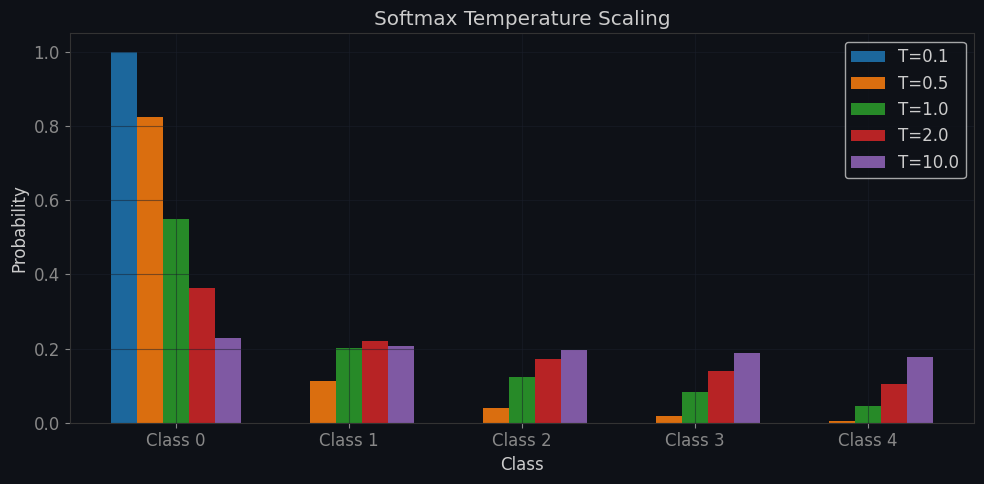

In [18]:
def softmax_temperature(x, T=1.0):
    """Softmax with temperature scaling."""
    # YOUR CODE HERE
    # return np.exp(x / T) / np.sum(np.exp(x/T), axis=-1, keepdims=1)
    return softmax(x/T)

# Visualize the effect of temperature
logits = np.array([2.0, 1.0, 0.5, 0.1, -0.5])
temperatures = [0.1, 0.5, 1.0, 2.0, 10.0]
labels = [f'T={t}' for t in temperatures]

fig, ax = plt.subplots(figsize=(10, 5))
x_pos = np.arange(len(logits))
width = 0.15

for i, T in enumerate(temperatures):
    probs = softmax_temperature(logits, T)
    ax.bar(x_pos + i * width, probs, width, label=labels[i], alpha=0.85)

ax.set_xlabel('Class')
ax.set_ylabel('Probability')
ax.set_title('Softmax Temperature Scaling')
ax.set_xticks(x_pos + width * 2)
ax.set_xticklabels([f'Class {i}' for i in range(len(logits))])
ax.legend()
plt.tight_layout()
plt.show()

---
## Part 5: GELU

### 5.1 — Implement GELU three ways

1. **Exact:** `x * Φ(x)` where Φ is the standard normal CDF
2. **Tanh approximation:** `0.5x(1 + tanh(√(2/π)(x + 0.044715x³)))` — this is what PyTorch uses
3. **Sigmoid approximation:** `x * σ(1.702x)`

In [19]:
from scipy.stats import norm

def gelu_exact(x):
    """Exact GELU using the normal CDF."""
    # YOUR CODE HERE
    return x * norm.cdf(x)

def gelu_tanh(x):
    """Tanh approximation of GELU (PyTorch default)."""
    approx_cdf = 0.5 * (1 + np.tanh(np.sqrt(2 / np.pi) * (x + 0.044715 * x**3)))
    return x * approx_cdf
    

def gelu_sigmoid(x):
    """Sigmoid approximation of GELU."""
    # YOUR CODE HERE (use your sigmoid from Part 1)
    approx_cdf = sigmoid(1.702 * x)
    return x * approx_cdf

### ✅ Checkpoint 5.1

In [20]:
test_x = np.linspace(-3, 3, 100)

exact = gelu_exact(test_x)
tanh_approx = gelu_tanh(test_x)
sig_approx = gelu_sigmoid(test_x)

# Tanh approximation should be very close to exact
assert np.allclose(exact, tanh_approx, atol=0.02), \
    f"Tanh approx max error: {np.max(np.abs(exact - tanh_approx)):.4f}"

# Sigmoid approximation is less accurate but still reasonable
assert np.allclose(exact, sig_approx, atol=0.05), \
    f"Sigmoid approx max error: {np.max(np.abs(exact - sig_approx)):.4f}"

# Key property: GELU(0) = 0
assert np.isclose(gelu_exact(0.0), 0.0, atol=1e-10)

# Non-monotonic: GELU has a minimum around x ≈ -0.5
# Check that there's a negative value in the output
assert np.min(exact) < 0, "GELU should have negative values (non-monotonic)"

print(f'Max error (tanh approx):    {np.max(np.abs(exact - tanh_approx)):.6f}')
print(f'Max error (sigmoid approx): {np.max(np.abs(exact - sig_approx)):.6f}')
print('\n✅ GELU: all tests passed!')

Max error (tanh approx):    0.000473
Max error (sigmoid approx): 0.020335

✅ GELU: all tests passed!


---
## Part 6: Swish / SiLU

### 6.1 — Implement Swish and its derivative

- **Swish:** `x · σ(βx)` (β is usually 1)
- **SiLU:** Swish with β = 1, i.e. `x · σ(x)`
- **Derivative:** `σ(x) + x · σ(x) · (1 − σ(x))` = `σ(x)(1 + x(1 − σ(x)))`

In [21]:
def swish(x, beta=1.0):
    # YOUR CODE HERE
    return x * sigmoid(beta * x)

def silu(x):
    """SiLU = Swish with beta=1"""
    # YOUR CODE HERE
    return x * sigmoid(x)

def silu_derivative(x):
    """Derivative of SiLU: σ(x)(1 + x(1 - σ(x)))"""
    # YOUR CODE HERE
    return sigmoid(x) * (1 + x * (1 - sigmoid(x)))
    

### ✅ Checkpoint 6.1

In [22]:
assert np.isclose(silu(0.0), 0.0), f"SiLU(0) should be 0, got {silu(0.0)}"
assert silu(5.0) > 0, "SiLU should be positive for large positive inputs"
assert silu(-5.0) < 0, "SiLU should be slightly negative for negative inputs"

# Verify derivative numerically
eps = 1e-5
test_pts = np.array([-2.0, -1.0, 0.0, 1.0, 2.0])
numerical_deriv = (silu(test_pts + eps) - silu(test_pts - eps)) / (2 * eps)
analytic_deriv = silu_derivative(test_pts)
assert np.allclose(numerical_deriv, analytic_deriv, atol=1e-4), \
    f"Derivative mismatch: numerical={numerical_deriv}, analytic={analytic_deriv}"

# Swish with different beta values
assert np.isclose(swish(1.0, beta=0), 0.5), "swish(1, beta=0) = 1 * sigmoid(0) = 0.5"

print('✅ Swish/SiLU: all tests passed!')

✅ Swish/SiLU: all tests passed!


---
## Part 7: Visualization — Compare Everything

### 7.1 — All activations on one plot

Create a figure with **two subplots side by side:**
1. Left: all activation functions
2. Right: all their derivatives

Include: Sigmoid, Tanh, ReLU, Leaky ReLU, GELU, SiLU

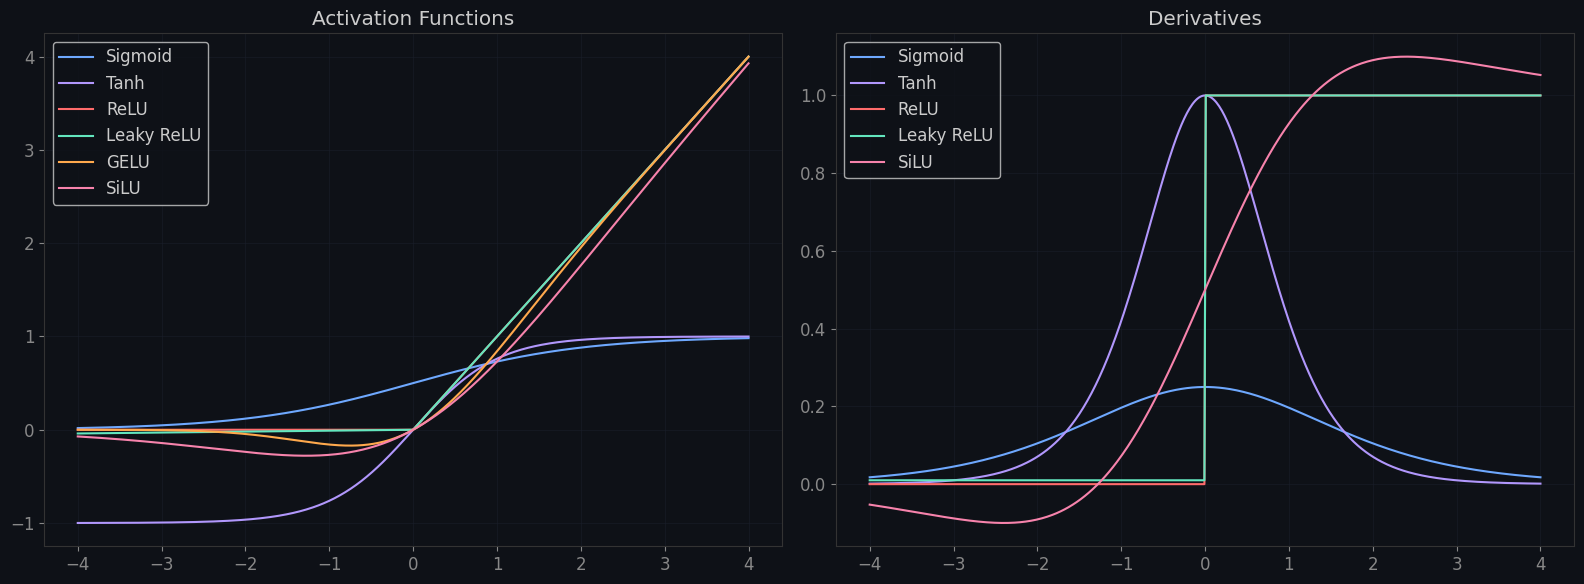

In [23]:
x = np.linspace(-4, 4, 500)

activations = {
    'Sigmoid': (sigmoid, sigmoid_derivative),
    'Tanh': (np.tanh, tanh_derivative),
    'ReLU': (relu, relu_derivative),
    'Leaky ReLU': (leaky_relu, leaky_relu_derivative),
    'GELU': (gelu_exact, None),   # Derivative optional here
    'SiLU': (silu, silu_derivative),
}

colors = ['#6ea8fe', '#b197fc', '#ff6b6b', '#63e6be', '#ffa94d', '#f783ac']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# YOUR CODE: Plot all activations on ax1, all derivatives on ax2
# Use the colors list for consistent styling
# Add legend, labels, and a horizontal line at y=0
for i, (name, (act, act_deriv)) in enumerate(activations.items()):
    ax1.plot(x, act(x), color=colors[i], label=name)
    if name != "GELU":
        ax2.plot(x, act_deriv(x), color=colors[i], label=name)
        ax2.legend()
    ax1.legend()
    

ax1.set_title('Activation Functions')
ax2.set_title('Derivatives')

plt.tight_layout()
plt.show()

### 7.2 — Gradient magnitude heatmap

**Task:** For a 10-layer network using each activation, compute how the gradient magnitude changes as it propagates backward through layers. This directly visualizes the vanishing gradient problem.

Assume: input = 0.5, each layer just applies the activation (no weights for simplicity).  
The gradient at layer $k$ is: $\prod_{i=k}^{L} f'(a_i)$ where $a_i$ is the pre-activation.

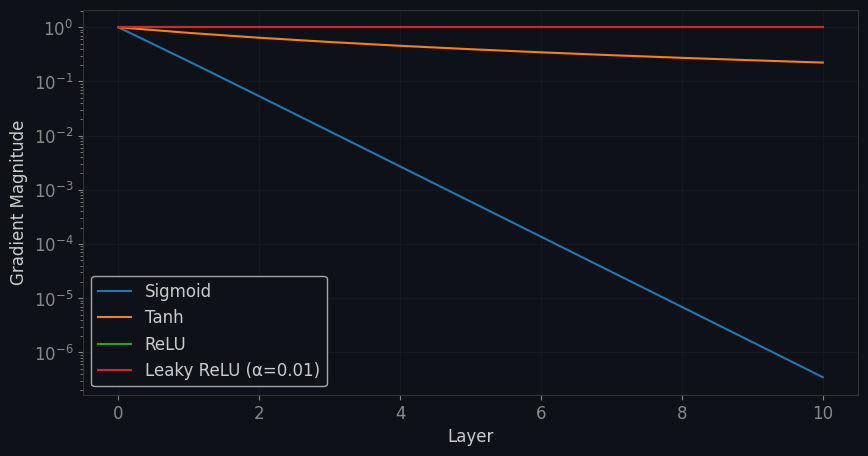

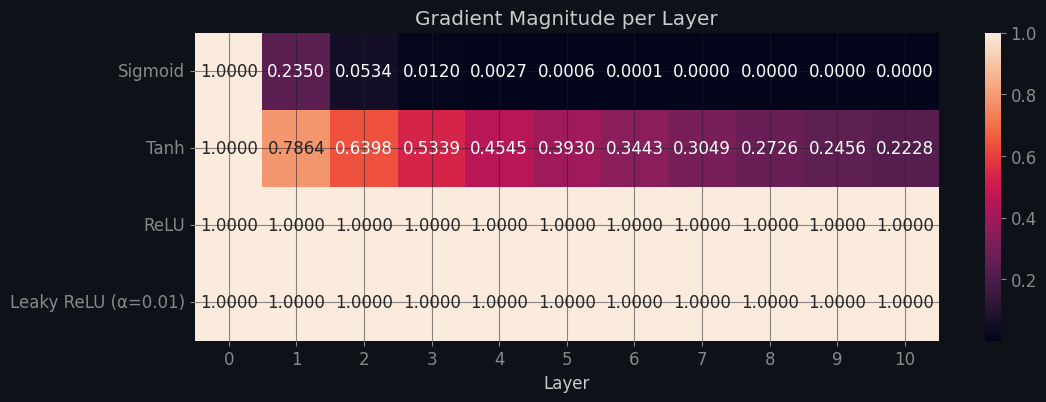

In [24]:
import seaborn as sns
n_layers = 10
initial_input = 0.5

activation_pairs = {
    'Sigmoid': (sigmoid, sigmoid_derivative),
    'Tanh': (np.tanh, tanh_derivative),
    'ReLU': (relu, relu_derivative),
    'Leaky ReLU (α=0.01)': (leaky_relu, leaky_relu_derivative),
}

# YOUR CODE:
# For each activation:
#   1. Forward pass: compute activation at each layer (output of layer i is input to layer i+1)
#   2. Backward pass: compute cumulative gradient product at each layer
#   3. Store the gradient magnitudes
#
# Create a heatmap or line plot showing gradient magnitude vs layer depth
# for each activation. Sigmoid should show clear vanishing gradients.
names = []
all_grads = []
for i, (name, (act, deriv_act)) in enumerate(activation_pairs.items()):
    x = initial_input
    forwards = [x]
    grad = 1.0
    grads = [1.0]
    for layer in range(n_layers):
        x = act(x)
        forwards.append(x)
    for layer in range(n_layers):
        grad *= deriv_act(forwards[layer])
        grads.append(grad)
    plt.plot(range(n_layers+1), grads, label=name)
    names.append(name)
    all_grads.append(grads)
plt.yscale('log')
plt.legend()
plt.xlabel('Layer')
plt.ylabel('Gradient Magnitude')
plt.show

plt.figure(figsize=(12, 4))
sns.heatmap(np.array(all_grads), 
            xticklabels=range(n_layers+1),
            yticklabels=names, 
            annot=True, fmt='.4f')
plt.xlabel('Layer')
plt.title('Gradient Magnitude per Layer')
plt.show()

---
## Part 8: Mini Neural Network with Custom Activations

### 8.1 — Two-layer network from scratch

Build a 2-layer neural network that classifies the **moons** dataset using ONLY your custom activation functions. No PyTorch, no sklearn models.

Architecture: `Input(2) → Linear(64) → Activation → Linear(2) → Softmax → Cross-Entropy Loss`

Train it with 3 different activations (ReLU, GELU, Sigmoid) and compare convergence.

For GELU use, (fn(x+eps) - fn(x-eps)) / 2*eps as the  approximation

In [25]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

# Generate data
X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# One-hot encode labels
def one_hot(y, n_classes=2):
    oh = np.zeros((len(y), n_classes))
    oh[np.arange(len(y)), y] = 1
    return oh

y_train_oh = one_hot(y_train)
y_test_oh = one_hot(y_test)

In [31]:
class TwoLayerNet:
    def __init__(self, input_dim, hidden_dim, output_dim, activation='relu'):
        """
        Initialize with He initialization for ReLU-like activations.
        activation: 'relu', 'gelu', or 'sigmoid'
        """
        scale = np.sqrt(2.0 / input_dim)
        self.W1 = np.random.randn(input_dim, hidden_dim) * scale
        self.b1 = np.zeros(hidden_dim)
        self.W2 = np.random.randn(hidden_dim, output_dim) * np.sqrt(2.0 / hidden_dim)
        self.b2 = np.zeros(output_dim)
        
        # Select activation
        if activation == 'relu':
            self.act_fn = relu
            self.act_deriv = relu_derivative
        elif activation == 'gelu':
            self.act_fn = gelu_tanh
            self.act_deriv = None  # Use numerical gradient
        elif activation == 'sigmoid':
            self.act_fn = sigmoid
            self.act_deriv = sigmoid_derivative
        else:
            raise ValueError(f"Unknown activation: {activation}")
        
        self.activation_name = activation
    
    def forward(self, X):
        """
        Forward pass. Cache intermediates for backward.
        Returns softmax probabilities.
        """
        # YOUR CODE HERE
        self.z1 = X @ self.W1 + self.b1
        self.a1 = self.act_fn(self.z1)
        self.z2 = self.a1 @ self.W2 + self.b2
        self.probs = softmax(self.z2)
        self.X = X

        return self.probs
    
    def compute_loss(self, probs, y_onehot):
        """Cross-entropy loss."""
        # YOUR CODE HERE
        loss = -np.mean(np.sum(y_onehot * np.log(probs + 1e-8), axis=1))
        return loss
    
    def backward(self, y_onehot):
        """
        Backward pass. Compute gradients for W1, b1, W2, b2.
        
        Key insight: gradient of cross-entropy + softmax simplifies to:
        dL/dz2 = probs - y_onehot   (this is the "free" simplification)
        """
        # YOUR CODE HERE
        N = len(y_onehot)
        self.dz2 = (self.probs - y_onehot) / N # (N,2)
        self.dw2 = self.a1.T @ self.dz2 # (64,2)
        self.db2 = np.sum(self.dz2, axis=0) # (2,)
        self.da1 = self.dz2 @ self.W2.T # (N,64)

        if self.act_deriv is not None:
            self.dz1 = self.da1 * self.act_deriv(self.z1) # (N,64)
        else: #gelu
            eps = 1e-5
            self.dz1 = self.da1 * (self.act_fn(self.z1 + eps) - self.act_fn(self.z1 - eps)) / (2 * eps)
        self.dw1 = self.X.T @ self.dz1 # (2,64)
        self.db1 = np.sum(self.dz1, axis=0) # (64,)
    
    def update(self, lr=0.1):
        """SGD update."""
        # YOUR CODE HERE
        self.W1 -= lr * self.dw1
        self.b1 -= lr * self.db1
        self.W2 -= lr * self.dw2
        self.b2 -= lr * self.db2
        
    
    def predict(self, X):
        probs = self.forward(X)
        return np.argmax(probs, axis=1)

In [32]:
# Train and compare
n_epochs = 300
lr = 0.5
activations_to_test = ['relu', 'sigmoid', 'gelu']
histories = {}

for act_name in activations_to_test:
    np.random.seed(42)  # Same init for fair comparison
    net = TwoLayerNet(2, 64, 2, activation=act_name)
    losses = []
    
    for epoch in range(n_epochs):
        probs = net.forward(X_train)
        loss = net.compute_loss(probs, y_train_oh)
        losses.append(loss)
        net.backward(y_train_oh)
        net.update(lr=lr)
    
    # Test accuracy
    preds = net.predict(X_test)
    acc = np.mean(preds == y_test)
    histories[act_name] = losses
    print(f"{act_name:>8s}: final loss = {losses[-1]:.4f}, test acc = {acc:.4f}")

    relu: final loss = 0.0960, test acc = 0.9900
 sigmoid: final loss = 0.2864, test acc = 0.8650
    gelu: final loss = 0.1012, test acc = 0.9900


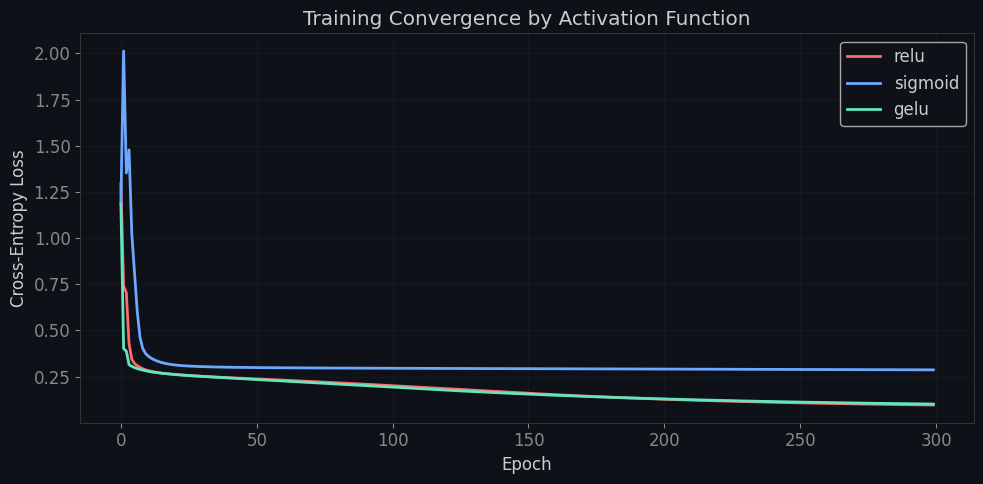

In [33]:
# Plot training curves
fig, ax = plt.subplots(figsize=(10, 5))
color_map = {'relu': '#ff6b6b', 'gelu': '#63e6be', 'sigmoid': '#6ea8fe'}

for name, losses in histories.items():
    ax.plot(losses, label=name, color=color_map[name], linewidth=2)

ax.set_xlabel('Epoch')
ax.set_ylabel('Cross-Entropy Loss')
ax.set_title('Training Convergence by Activation Function')
ax.legend()
plt.tight_layout()
plt.show()

---
## Part 9: Conceptual Questions

Answer these in your own words. Practice saying them out loud — these are real interview questions.

### Q1: Why do we need non-linear activation functions?

*Your answer*: We need non-linear activation functions to learn more complex relations between the inputs and output. Without non-linearity, stacking multiple linear layers collapses into a single linear transformation (W2 @ W1 @ x = W_combined @ x), so the network can only learn linear decision boundaries no matter how deep it is.


### Q2: What is the dying ReLU problem, and name three ways to fix it.

*Your answer:* if the neuron always outputs negative value, the nueron after RELU is always 0 and never gets active, this is dying ReLU problem. It can be fixed by changing the activation function to Leaky ReLU, PRELU or something like GELU/SwiGLu.

Mention why it happens — large negative bias or a big gradient update can push weights so that the pre-activation is always negative
The fixes are good, but also mention: proper weight initialization (He init) and using a smaller learning rate


### Q3: Why does BERT use GELU instead of ReLU? What's the probabilistic interpretation?

*Your answer:*
The practical reason: GELU is smooth everywhere — no hard kink at zero like ReLU. This gives smoother loss landscapes, which helps with the optimization dynamics of transformer training. Empirically, the BERT authors found GELU consistently gave small accuracy improvements over ReLU and ELU on transformer benchmarks.
The probabilistic interpretation: GELU is x * Φ(x), where Φ(x) is the CDF of a standard normal. So each input gets weighted by the probability that it's greater than a random sample from N(0,1). Inputs that are clearly positive (x = 3) get Φ(3) ≈ 1, so they pass through almost fully. Inputs that are clearly negative (x = -3) get Φ(-3) ≈ 0, so they're nearly zeroed. Inputs near zero get a soft, probabilistic blend — unlike ReLU which makes a hard binary decision at exactly zero.
Why this matters for transformers specifically: Transformer FFN layers process every token position, and the inputs at each position come from attention-weighted combinations which tend to be roughly normally distributed. GELU's soft gating based on a normal CDF is a natural fit for this distribution of inputs. ReLU's hard cutoff at zero is somewhat arbitrary in comparison.
The honest caveat: The performance difference between GELU and ReLU in transformers is small. Once BERT used GELU and showed good results, it became the convention and everyone followed. The choice of learning rate, normalization, and architecture matter more than the specific smooth activation you pick.
That last part is important in interviews — it shows you understand that not everything has a deep theoretical justification and that you can distinguish between "this worked empirically and became convention" vs "there's a strong theoretical reason."

### Q4: Explain the relationship between softmax temperature and model behavior in LLMs.

*Your answer:* 
High T → flatter/more uniform distribution → more random/diverse sampling
Low T → sharper/peakier distribution → more confident/deterministic
T=1 is the default, T→∞ gives uniform, T→0 gives argmax


### Q5: What is SwiGLU and why does LLaMA use it?

*Your answer:*
SwiGLU is a feed-forward network architecture, not just an activation function. A standard transformer FFN does W2 · GELU(W1·x) — one projection, activate, project back. SwiGLU replaces this with W2 · (Swish(W1·x) ⊙ W3·x), where W1 and W3 are two separate weight matrices and ⊙ is element-wise multiplication.
The idea comes from Gated Linear Units (Dauphin et al., 2017). The W3·x branch is a learned gate that controls which features from the Swish(W1·x) branch pass through. Regular activations make a unilateral decision — ReLU zeros anything negative, GELU soft-gates based on input magnitude. SwiGLU adds a separate learned projection that decides what to let through, giving the network multiplicative interactions that are more expressive.
LLaMA uses it because Shazeer (2020) showed gated FFN variants consistently give better perplexity per parameter than standard FFNs. The cost is one extra weight matrix, but at the same total parameter budget SwiGLU still wins. PaLM, LLaMA 1 & 2, and Mistral all adopted it.
If asked about variants: replace Swish with GELU you get GeGLU, with ReLU you get ReGLU. The activation name is the prefix, GLU is the gating pattern. SwiGLU was marginally best in Shazeer's experiments but the differences between gated variants are small — the big win is gating itself over no gating.


### Q6: If you're designing a new transformer, how do you choose the activation function for the FFN layers? What about the output layer?

*Your answer:*
**FFN layers (hidden activation):**

Start with GELU or SwiGLU — these are the current defaults and you'd need a good reason to deviate. If you're building a large language model and have the parameter budget, SwiGLU is the stronger choice (LLaMA, PaLM, Mistral all validated this). If you want simplicity or are working with a smaller model, GELU is safe and proven (BERT, GPT-2, GPT-3, ViT). ReLU works but there's no reason to pick it over GELU in a transformer — it's strictly a downgrade based on existing evidence.

**Output layer — depends entirely on the task:**

Classification (single label): softmax over classes. Binary classification: sigmoid. Language modeling (next token prediction): softmax over vocabulary, often with temperature scaling at inference. Regression: no activation (linear output). Generation with bounded outputs (e.g., pixel values in [-1, 1]): tanh.

The activation function in the FFN matters less than architecture decisions like normalization (pre-norm vs post-norm), attention mechanism, depth, and training recipe. The difference between GELU and SwiGLU is real but small. The difference between any modern smooth activation and sigmoid in hidden layers is large.

---
## Part 10: PyTorch Validation

Validate your from-scratch implementations against PyTorch's built-in versions.

In [23]:
import torch
import torch.nn.functional as F

test_np = np.array([-3.0, -1.0, -0.5, 0.0, 0.5, 1.0, 3.0])
test_pt = torch.tensor(test_np, dtype=torch.float64)

validations = [
    ('Sigmoid',    sigmoid(test_np),          torch.sigmoid(test_pt).numpy()),
    ('Tanh',       np.tanh(test_np),          torch.tanh(test_pt).numpy()),
    ('ReLU',       relu(test_np),             F.relu(test_pt).numpy()),
    ('Leaky ReLU', leaky_relu(test_np, 0.01), F.leaky_relu(test_pt, 0.01).numpy()),
    ('GELU',       gelu_tanh(test_np),        F.gelu(test_pt, approximate='tanh').numpy()),
    ('SiLU',       silu(test_np),             F.silu(test_pt).numpy()),
    ('Softmax',    softmax(test_np),          F.softmax(test_pt, dim=0).numpy()),
    ('Log Softmax',log_softmax(test_np),      F.log_softmax(test_pt, dim=0).numpy()),
]

print(f'{"Function":<14} {"Max Error":<14} {"Status"}')
print('-' * 42)
for name, ours, theirs in validations:
    err = np.max(np.abs(ours - theirs))
    status = '✅' if err < 1e-5 else '⚠️' if err < 1e-2 else '❌'
    print(f'{name:<14} {err:<14.2e} {status}')

Function       Max Error      Status
------------------------------------------
Sigmoid        5.55e-17       ✅
Tanh           0.00e+00       ✅
ReLU           0.00e+00       ✅
Leaky ReLU     0.00e+00       ✅
GELU           5.55e-17       ✅
SiLU           4.44e-16       ✅
Softmax        1.39e-17       ✅
Log Softmax    0.00e+00       ✅


---

## 🎯 Summary Checklist

Before moving on, make sure you can:

- [ ] Implement all 7 activation functions from memory (no reference)
- [ ] Write numerically stable sigmoid and softmax under interview pressure
- [ ] Compute the softmax Jacobian
- [ ] Explain dying ReLU, vanishing gradients, and zero-centering to an interviewer
- [ ] Justify GELU for transformers and SiLU/SwiGLU for LLaMA
- [ ] Implement a mini neural network using only custom activations
- [ ] Explain softmax temperature scaling for LLM sampling

**Next up:** Backpropagation — implementing the full backward pass for multi-layer networks.